In [1]:
%cd ../

/home/maia-user/NeuroCBIR-Clinic


In [ ]:
# ==========================
# CONFIG
# ==========================
JSON_PATH = "results/evaluate_retrieval_age.json"
METADATA_PATH = "/home/maia-user/cifs/Datasets/combined_metadata.csv" # Assuming this is where disease labels are
WHOLE_BRAIN_EMB_PATH = "data/data_private/whole_brain/projected_embeddings.parquet"
REGION_BRAIN_EMB_PATH = "data/data_private/region_brain/projected_embeddings.parquet"
LABELS_PATH = "data/labels.csv"
BB_PATH = "data/bounding_boxes.csv"
OUT_DIR = "figures"
TOP_K_TO_REPORT = "500"
FIG_DPI = 600
PLOT_REGION = "Left-Hippocampus"  # Define the region to plot
DISEASE_MAPPING = {
    "CN": "CN", "Normal": "CN", "Control": "CN",
    "MCI": "MCI", "Mild Cognitive Impairment": "MCI", "EMCI": "MCI", "LMCI": "MCI", "SMC": "MCI",
    "AD": "AD", "Alzheimer's Disease": "AD"
}

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
import logging
from tqdm import tqdm
import seaborn as sns

plt.style.use('default')
plt.rcParams.update({'font.size': 8})

os.makedirs(OUT_DIR, exist_ok=True)

def get_age_range(age):
    try:
        age_val = float(age)
        if np.isnan(age_val):
            return 'Unknown'
        low = 5 * int(age_val // 5)
        high = low + 4
        return f'{int(low)}-{int(high)}'
    except Exception:
        return 'Unknown'

def load_clinical_data(ds_path, disease_mapping):   
    # Load and filter metadata
    clinical_ds = pd.read_csv(ds_path)
    clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)
    
    # Map disease categories
    clinical_ds['disease_cat'] = clinical_ds['disease'].map(disease_mapping).fillna("Other")
    
    # Filter out rows
    clinical_ds = clinical_ds.query("repet == 1").reset_index(drop=True)
    clinical_ds = clinical_ds.query("useable == 1").reset_index(drop=True)
    clinical_ds = clinical_ds.query("mislabel == 0").reset_index(drop=True)
    clinical_ds['subject'].replace('', pd.NA, inplace=True)
    clinical_ds = clinical_ds.dropna(subset=['subject']).reset_index(drop=True)
    
    # Fill missing values and compute age ranges
    clinical_ds = clinical_ds.fillna('Unknown')
    clinical_ds = clinical_ds[clinical_ds["age"] != "Unknown"].reset_index(drop=True)
    clinical_ds['age_range'] = clinical_ds['age'].apply(get_age_range)
    clinical_ds["disease_end"] = clinical_ds.groupby("subject")["disease_cat"].transform(
        lambda x: "AD" if "AD" in x.values else x.iloc[0]
    )
    
    
    return clinical_ds
    
def _process_dataset(dataset, df_embs, id_cols):
    """Applies common processing steps to the merged dataset."""
    embedding_cols = [col for col in df_embs.columns if col not in id_cols]
    dataset["features"] = dataset[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)
    dataset = dataset.drop(columns=embedding_cols)
    dataset = dataset.fillna('Unknown')
    return dataset

def load_dataset_whole_brain(ds_path, emb_path):
    """
    Loads and prepares the whole-brain dataset by merging clinical data with embeddings.
    """
    # 1. Load clinical data
    clinical_ds = load_clinical_data(ds_path, DISEASE_MAPPING)

    # 2. Load embeddings
    df_embs = pd.read_parquet(emb_path)
    df_embs["GUID"] = df_embs["GUID"].astype(str)

    # 3. Merge
    dataset = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

    # 4. Process and clean
    id_cols = ["GUID"]
    dataset = _process_dataset(dataset, df_embs, id_cols)
    
    # 5. Add "LabelName" column with "whole_brain" value
    dataset["LabelName"] = "whole_brain"

    return dataset

def load_dataset_region_brain(ds_path, emb_path, labels_path="data/labels.csv", bb_path="data/bounding_boxes.csv"):
    """
    Loads and prepares the region-based dataset by merging clinical data with embeddings.
    """
    # 1. Load clinical data
    clinical_ds = load_clinical_data(ds_path, DISEASE_MAPPING)

    # 2. Load embeddings
    df_embs = pd.read_parquet(emb_path)
    df_embs["GUID"] = df_embs["GUID"].astype(str)
    df_embs["LabelName"] = df_embs["LabelName"].astype(str)

    # 3. Merge
    dataset = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

    # 4. Process and clean
    id_cols = ["GUID", "LabelName"]
    dataset = _process_dataset(dataset, df_embs, id_cols)

    # Load labels and bounding boxes for cortical/subcortical structures
    labels_df = pd.read_csv(labels_path)
    bb_df = pd.read_csv(bb_path)
    labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column

    return dataset, labels_bb_df

def retrieve_topk_for_query(query_features, 
                            dataset, 
                            top_k = 3, 
                            feature_column = "features", 
                            guid_column = "GUID"
                            ):
    """
    Retrieve the top-k most similar entries for a subset of queries, 
    using cosine similarity against the full dataset as the retrieval pool.

    Args:
        query_features (np.array): features of the query.
        dataset (pd.DataFrame): Full pool of entries with features and GUIDs.
        top_k (int): Number of top similar entries to retrieve.
        feature_column (str): Column containing the feature vectors.
        guid_column (str): Column with unique scan identifiers (e.g., 'GUID').

    Returns:
        pd.DataFrame: Retrieval results. One row per query, first column is the query GUID,
                      followed by the GUIDs of the top-k retrieved entries.
    """
    # Retrieval pool
    features_matrix = np.stack(dataset[feature_column].values)
    guids = dataset[guid_column].values

    # Compute similarities
    similarities = cosine_similarity(query_features, features_matrix)[0]
        
    # Get top-k
    top_k_indices = np.argsort(similarities)[::-1][:top_k]
    
    return guids[top_k_indices].tolist()



In [ ]:

# ==========================
# HELPER FUNCTIONS (adapted from evaluate_retrieval_age.py)
# ==========================
def evaluate_region_age(query_dataset, retrieval_dataset, region_name, top_k=300, logger=None, alpha=1.0):
    """Evaluate retrieval for a specific region using top-k similarity with soft inverse-prior weighting."""

    # Filter region
    embs_query = (
        query_dataset
        .query(f"LabelName == '{PLOT_REGION}'")
        .reset_index(drop=True)
    )
    
    embs_retrieval = (
        retrieval_dataset
        .query(f"LabelName == '{PLOT_REGION}'")
        .reset_index(drop=True)
    )

    if embs_query.empty:
        logger.warning(f"No samples found for region {region_name}. Skipping.")
        return []

    X = np.vstack(embs_query["features"].to_numpy())
    # Compute age distribution in the full dataset (priors)
    embs_retrieval["age_rounded"] = 2*(embs_retrieval["age"].astype(float) // 2)
    age_counts_full = embs_retrieval["age_rounded"].value_counts(normalize=True).to_dict()

    true_ages = []
    pred_ages = []

    for i in tqdm(range(len(embs_query)), desc=f"Evaluating {region_name}"):
        query_subject = embs_query.loc[i, "subject"]
        query_age = embs_query.loc[i, "age"].astype(float)
        z_q = np.expand_dims(X[i], axis=0)

        # Exclude query from retrieval set
        embs_retrieval_excl = embs_retrieval[embs_retrieval["subject"] != query_subject].reset_index(drop=True)
        # Retrieve top-k similar samples
        top_k_retrieved_all = retrieve_topk_for_query(z_q, embs_retrieval_excl, top_k=top_k)

        retrieved_subset = top_k_retrieved_all[:top_k]
        retrieved_df = embs_retrieval_excl[embs_retrieval_excl["GUID"].isin(retrieved_subset)].copy()
        if len(retrieved_df) == 0:
            continue

        retrieved_df["age"] = retrieved_df["age"].astype(float)

        # Soft inverse-prior weighting
        retrieved_df["age_weight"] = retrieved_df["age_rounded"].map(
            lambda a: (1.0 / age_counts_full.get(a, 1e-6)) ** alpha
        )
        retrieved_df["age_weight"] /= retrieved_df["age_weight"].sum()

        retrieved_avg_age = np.average(retrieved_df["age"], weights=retrieved_df["age_weight"])
        
        # if query_age < 60.0:
        #     print(query_age)
        #     print(retrieved_avg_age)
        #     print(retrieved_df["age"])
        #     print(retrieved_df["age_weight"])
        #     halt
        
        true_ages.append(query_age)
        pred_ages.append(retrieved_avg_age)

    return np.array(true_ages), np.array(pred_ages)



In [3]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)
logger.info("Starting age prediction plotting...")

# Load datasets
dataset_whole_brain = load_dataset_whole_brain(METADATA_PATH, WHOLE_BRAIN_EMB_PATH)
dataset_region_brain, labels_bb_df = load_dataset_region_brain(METADATA_PATH, REGION_BRAIN_EMB_PATH,
                                                                labels_path=LABELS_PATH, bb_path=BB_PATH)

dataset = pd.concat([dataset_whole_brain, dataset_region_brain], ignore_index=True)
logger.info(f"Loaded combined dataset with {len(dataset)} samples.")

# Filter out unknown ages and convert to float, and age >= 50
dataset = dataset[dataset["age"] != "Unknown"].reset_index(drop=True)
dataset["age"] = dataset["age"].astype(float)
dataset = dataset.query("age >= 50").reset_index(drop=True)

cn_dataset = dataset[dataset["disease_end"] == "CN"].reset_index(drop=True)
ad_dataset = dataset[dataset["disease_end"] == "AD"].reset_index(drop=True)

# Filter for CN and AD cases
# filter out ages under percentile 5 and over percentile 95
query_dataset = dataset[
    (dataset["age"] >= dataset["age"].quantile(0.05)) &
    (dataset["age"] <= dataset["age"].quantile(0.95))
].reset_index(drop=True)
cn_query_dataset = query_dataset[query_dataset["disease_end"] == "CN"].reset_index(drop=True)
ad_query_dataset = query_dataset[query_dataset["disease_end"] == "AD"].reset_index(drop=True)

logger.info(f"CN samples: {len(cn_query_dataset)}")
logger.info(f"AD samples: {len(ad_query_dataset)}")
# Define the region to plot (e.g., "whole_brain")
# This script will plot for 'whole_brain' as an example,
# but could be extended to loop through regions if needed.

2026-01-24 19:11:48,091 [INFO] Starting age prediction plotting...
/home/maia-user/NeuroCBIR-Clinic/utils/utils.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clinical_ds['subject'].replace('', pd.NA, inplace=True)
/home/maia-user/NeuroCBIR-Clinic/utils/utils.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', Tr

In [4]:

# --- Predict age for CN queries (using CN dataset for retrieval) ---
logger.info(f"Predicting age for CN queries in {PLOT_REGION}...")
cn_true_ages, cn_pred_ages = evaluate_region_age(
    query_dataset=cn_query_dataset, 
    retrieval_dataset=cn_dataset, 
    region_name=PLOT_REGION, 
    top_k=int(TOP_K_TO_REPORT), 
    logger=logger
)

# --- Predict age for AD queries (using CN dataset for retrieval) ---
logger.info(f"Predicting age for AD queries in {PLOT_REGION} using CN dataset for retrieval...")
ad_true_ages, ad_pred_ages = evaluate_region_age(
    query_dataset=ad_query_dataset, 
    retrieval_dataset=cn_dataset, # IMPORTANT: AD queries use CN dataset for retrieval
    region_name=PLOT_REGION, 
    top_k=int(TOP_K_TO_REPORT), 
    logger=logger
)


2026-01-24 19:11:59,201 [INFO] Predicting age for CN queries in Left-Hippocampus...
Evaluating Left-Hippocampus: 100%|██████████| 5552/5552 [01:03<00:00, 88.04it/s]
2026-01-24 19:13:02,305 [INFO] Predicting age for AD queries in Left-Hippocampus using CN dataset for retrieval...
Evaluating Left-Hippocampus: 100%|██████████| 1585/1585 [00:17<00:00, 91.12it/s]


In [5]:

# Fit on CN only
lr = LinearRegression()
lr.fit(cn_true_ages.reshape(-1, 1), cn_pred_ages)

alpha = lr.intercept_
beta = lr.coef_[0]

# CN Correct predicted age
cn_pred_ages_corrected = (cn_pred_ages - alpha) / beta

# Age gaps
cn_age_gaps = cn_pred_ages - cn_true_ages
cn_age_gaps_corrected = cn_pred_ages_corrected - cn_true_ages

# AD predicted ages correction
ad_pred_ages_corrected = (ad_pred_ages - alpha) / beta

# Age gaps
ad_age_gaps = ad_pred_ages - ad_true_ages
ad_age_gaps_corrected = ad_pred_ages_corrected - ad_true_ages

2026-01-24 19:19:47,411 [INFO] CN Pearson r: 0.46
2026-01-24 19:19:47,411 [INFO] CN MAE: 5.26
2026-01-24 19:19:47,440 [INFO] AD Pearson r (CN Retrieval): 0.22


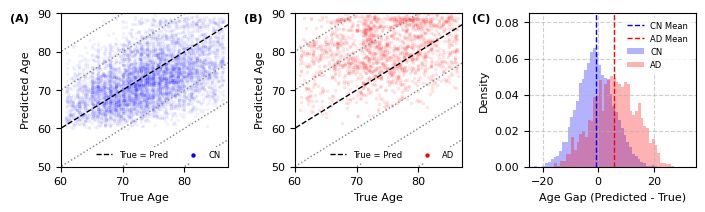

2026-01-24 19:19:48,671 [INFO] [OK] Age prediction summary figure saved to figures/age_prediction_summary.pdf


In [7]:
# ==========================
# PLOTTING with Seaborn
# ==========================
# Figure with three subplots: CN and AD age scatter, age gap histogram (CN and AD) and brain age gap histogram (CN and AD)
inch = 2.54  # cm to inch conversion
fig, axes = plt.subplots(1, 3, figsize=(18/inch, 5.5/inch), 
                        #  constrained_layout=True
                         )
# fig, axes = plt.subplots(3, 1, figsize=(9/inch, 15/inch), constrained_layout=True)

# ==========================
# Subplot 1: Scatter plot (Chronological Age vs Predicted Age) for CN
# ==========================

# ax0.plot([], [], alpha=0.7, color="grey", linewidth=1, linestyle=":", label="Iso-age lines")


USE_CORRECTED = False

if USE_CORRECTED:
    cn_pred_ages_to_plot = cn_pred_ages_corrected
    ad_pred_ages_to_plot = ad_pred_ages_corrected
    cn_age_gaps_to_plot = cn_age_gaps_corrected
    ad_age_gaps_to_plot = ad_age_gaps_corrected
else:
    cn_pred_ages_to_plot = cn_pred_ages
    ad_pred_ages_to_plot = ad_pred_ages
    cn_age_gaps_to_plot = cn_age_gaps
    ad_age_gaps_to_plot = ad_age_gaps
    
    
ax0 = axes[0]
# Plot iso-age reference lines first
for i in range(-100, 100, 10):
    if i == 0:
        continue
    ax0.plot(
        [i, 100 + i], [0, 100],
        alpha=1,
        color="grey",
        linewidth=1,
        linestyle=":",
        label="_nolegend_"
    )

# Plot True Age = Predicted Age line
ax0.plot([0, 100], [0, 100], 'k--', label='True = Pred', linewidth=1)

if cn_true_ages is not None and cn_pred_ages is not None:
    sns.scatterplot(x=cn_true_ages, y=cn_pred_ages_to_plot, alpha=0.05, s=5, color="blue", label="__nolegend__", edgecolor=None, ax=ax0, 
                    rasterized=True)
    logger.info(f"CN Pearson r: {pearsonr(cn_true_ages, cn_pred_ages_to_plot)[0]:.2f}")
    logger.info(f"CN MAE: {np.mean(np.abs(cn_pred_ages_to_plot - cn_true_ages)):.2f}")
ax0.scatter([], [], color="blue", s=10, label="CN", linewidth=0)

ax0.set_xlim(60, 87)
ax0.set_ylim(50, 90)
ax0.set_xlabel("True Age")
ax0.set_ylabel("Predicted Age")
ax0.set_title("")
leg1 = ax0.legend(loc='lower right', ncol=4, fontsize=6, 
                  framealpha=1.0,
                #   bbox_to_anchor = [-0.02, 1.02]
                  )
leg1.get_frame().set_linewidth(0.0)
# ax0.grid(True, linestyle='--', alpha=0.6)
# remove legend, do not plot
# ax0.get_legend().remove()

# ==========================
# Subplot 2: Scatter plot (Chronological Age vs Predicted Age) for AD
# ==========================

ax1 = axes[1]

# Plot iso-age reference lines first
for i in range(-100, 100, 10):
    if i == 0:
        continue
    ax1.plot(
        [i, 100 + i], [0, 100],
        alpha=1,
        color="grey",
        linewidth=1,
        linestyle=":",
        label="_nolegend_"
    )   
    
# Plot True Age = Predicted Age line
ax1.plot([0, 100], [0, 100], 'k--', label='True = Pred', linewidth=1)
    
if ad_true_ages is not None and ad_pred_ages is not None:
    sns.scatterplot(x=ad_true_ages, y=ad_pred_ages_to_plot, alpha=0.1, s=5, color="red", label="__nolegend__", edgecolor=None, ax=ax1, rasterized=True)
    logger.info(f"AD Pearson r (CN Retrieval): {pearsonr(ad_true_ages, ad_pred_ages_to_plot)[0]:.2f}")
    
ax1.scatter([], [], color="red", s=10, label="AD", linewidth=0)


ax1.set_xlim(60, 87)
ax1.set_ylim(50, 90)
ax1.set_xlabel("True Age")
ax1.set_ylabel("Predicted Age")
ax1.set_title("")
leg1 = ax1.legend(loc='lower right', ncol=4, fontsize=6, 
                  framealpha=1.0,
                #   bbox_to_anchor = [-0.02, 1.02]
                  )
leg1.get_frame().set_linewidth(0.0)
# ax0.grid(True, linestyle='--', alpha=0.6)
# remove legend, do not plot
# ax0.get_legend().remove()


# ==========================
# Subplot 2: Age Gap Histogram (CN and AD)
# ==========================
ax2 = axes[2]
if cn_age_gaps is not None and len(cn_age_gaps) > 0:
    sns.histplot(cn_age_gaps_to_plot, kde=False, color="blue", label="CN", ax=ax2, stat="density", common_norm=False, edgecolor=None, linewidth=0, binwidth=1, alpha=0.3)
if ad_age_gaps is not None and len(ad_age_gaps) > 0:
    sns.histplot(ad_age_gaps_to_plot, kde=False, color="red", label="AD", ax=ax2, stat="density", common_norm=False, edgecolor=None, linewidth=0, binwidth=1, alpha=0.3)
# add vertical line at the mean age gap for each group
if cn_age_gaps is not None and len(cn_age_gaps) > 0:
    cn_mean_gap = np.mean(cn_age_gaps_to_plot)
    ax2.axvline(cn_mean_gap, color='blue', linestyle='--', linewidth=1, label='CN Mean')
if ad_age_gaps is not None and len(ad_age_gaps) > 0:
    ad_mean_gap = np.mean(ad_age_gaps_to_plot)
    ax2.axvline(ad_mean_gap, color='red', linestyle='--', linewidth=1, label='AD Mean')

# ax2.set_xticklabels(ax2.get_xticks().astype(int), fontsize=6)
ax2.set_ylim(0, 0.085)
ax2.set_xlim(-25, 35)
ax2.set_xlabel("Age Gap (Predicted - True)")
ax2.set_ylabel("Density")
ax2.set_title("")
leg2 = ax2.legend(loc='upper right', fontsize=6, 
                #   ncol=2,
                #   bbox_to_anchor = [0.0, 1.02]
                  )
leg2.get_frame().set_linewidth(0.0)
ax2.grid(True, linestyle='--', alpha=0.6)

# add (C) at the top left of subplot 2

# ==========================
# Subplot 3: Brain Age Gap vs Real Age (CN and AD)
# Assuming brain age gap is the same as age gap for now based on context
# ==========================
# ax2 = axes[2]
# if cn_age_gaps is not None and len(cn_age_gaps) > 0:
#     sns.scatterplot(x=cn_true_ages, y=cn_age_gaps_to_plot, alpha=0.05, s=4, color="blue", label="CN Queries", edgecolor=None, ax=ax2)
#     # sns.histplot(cn_age_gaps, kde=True, color="blue", label="CN Queries", ax=ax2, stat="density", common_norm=False)
# if ad_age_gaps is not None and len(ad_age_gaps) > 0:
#     sns.scatterplot(x=ad_true_ages, y=ad_age_gaps_to_plot, alpha=0.1, s=4, color="red", label="AD Queries", edgecolor=None, ax=ax2)
#     # sns.histplot(ad_age_gaps, kde=True, color="red", label="AD Queries (CN Retrieval)", ax=ax2, stat="density", common_norm=False)
    
# # 0 gap line
# ax2.axhline(0, color='k', linestyle='--', linewidth=1, label='_nolegend_')

# ax2.set_xlim(60, 87)
# ax2.set_ylim(-25, 35)
# ax2.set_xlabel("True Age")
# ax2.set_ylabel("Brain Age Gap")
# ax2.set_title("")
# leg3 = ax2.legend(loc='lower left', fontsize=6, bbox_to_anchor = [-0.02, -0.02])
# leg3.get_frame().set_linewidth(0.0)
# ax2.grid(True, linestyle='--', alpha=0.6)

ax0.text(-0.19, 1.0, "(A)", transform=ax0.transAxes, fontsize=8, va='top', ha='right', fontweight='bold')
ax1.text(-0.19, 1.0, "(B)", transform=ax1.transAxes, fontsize=8, va='top', ha='right', fontweight='bold')
ax2.text(-0.23, 1.0, "(C)", transform=ax2.transAxes, fontsize=8, va='top', ha='right', fontweight='bold')


# add separation space between subplots
# 
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)

fig_path = os.path.join(OUT_DIR, f"{PLOT_REGION}_age_prediction_summary_top{TOP_K_TO_REPORT}.pdf")
plt.savefig(fig_path, format='pdf', dpi=FIG_DPI, bbox_inches='tight', pad_inches=0)
fig_path = os.path.join(OUT_DIR, f"age_prediction_summary.pdf")
plt.savefig(fig_path, format='pdf', dpi=FIG_DPI, bbox_inches='tight', pad_inches=0)
plt.show()

logger.info(f"[OK] Age prediction summary figure saved to {fig_path}")
